# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

# How to estimate the price of a used car?

The project is to find out the features which influences a used car price. Using those, develop sevaral ML algorhithms and finally find an optionmal algorithm that can predict the price of a used car.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Load the data and analyze the data frame

In [8]:
import pandas as pd
from sklearn.compose import make_column_transformer, make_column_selector
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.datasets import fetch_california_housing
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

In [9]:
vehicles_asis = pd.read_csv('data/vehicles.csv')

In [10]:
vehicles_asis.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Find the NULL values of each features

In [12]:
vehicles_asis.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [13]:
vehicles_raw = vehicles_asis
vehicles_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [14]:
vehicles_raw

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy


### Changing Object to String and Analyze the catergorical feature

In [16]:
vehicles_raw = vehicles_raw.convert_dtypes()
vehicles_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            426880 non-null  Int64 
 1   region        426880 non-null  string
 2   price         426880 non-null  Int64 
 3   year          425675 non-null  Int64 
 4   manufacturer  409234 non-null  string
 5   model         421603 non-null  string
 6   condition     252776 non-null  string
 7   cylinders     249202 non-null  string
 8   fuel          423867 non-null  string
 9   odometer      422480 non-null  Int64 
 10  title_status  418638 non-null  string
 11  transmission  424324 non-null  string
 12  VIN           265838 non-null  string
 13  drive         296313 non-null  string
 14  size          120519 non-null  string
 15  type          334022 non-null  string
 16  paint_color   296677 non-null  string
 17  state         426880 non-null  string
dtypes: Int64(4), string(14)


In [17]:
vehicles_raw.region.unique()

<StringArray>
[              'prescott',           'fayetteville',           'florida keys',
 'worcester / central MA',             'greensboro',          'hudson valley',
        'medford-ashland',                   'erie',                'el paso',
             'bellingham',
 ...
             'eau claire',              'green bay',             'janesville',
         'kenosha-racine',                'madison',              'milwaukee',
            'northern WI',              'sheboygan',                 'wausau',
                'wyoming']
Length: 404, dtype: string

In [18]:
vehicles_raw.manufacturer.unique()

<StringArray>
[             <NA>,             'gmc',       'chevrolet',          'toyota',
            'ford',            'jeep',          'nissan',             'ram',
           'mazda',        'cadillac',           'honda',           'dodge',
           'lexus',          'jaguar',           'buick',        'chrysler',
           'volvo',            'audi',        'infiniti',         'lincoln',
      'alfa-romeo',          'subaru',           'acura',         'hyundai',
   'mercedes-benz',             'bmw',      'mitsubishi',      'volkswagen',
         'porsche',             'kia',           'rover',         'ferrari',
            'mini',         'pontiac',            'fiat',           'tesla',
          'saturn',         'mercury', 'harley-davidson',          'datsun',
    'aston-martin',      'land rover',          'morgan']
Length: 43, dtype: string

In [19]:
vehicles_raw.model.unique()

<StringArray>
[                            <NA>,       'sierra 1500 crew cab slt',
                 'silverado 1500',            'silverado 1500 crew',
           'tundra double cab sr',                      'f-150 xlt',
    'sierra 2500 hd extended cab',          'silverado 1500 double',
                         'tacoma',          'colorado extended cab',
 ...
                     'cruze, 2lt',                        '2500 ls',
 'Thunder Creek Fuel Trailer MT2',                       '1500 z71',
                   'cj 3a willys',                  'rx& gls sport',
                            'ATI',                  'gand wagoneer',
                    '96 Suburban',        'Paige Glenbrook Touring']
Length: 29650, dtype: string

In [20]:
vehicles_raw.condition.unique()

<StringArray>
[<NA>, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage']
Length: 7, dtype: string

In [21]:
vehicles_raw.cylinders.unique()

<StringArray>
[          <NA>,  '8 cylinders',  '6 cylinders',  '4 cylinders',
  '5 cylinders',        'other',  '3 cylinders', '10 cylinders',
 '12 cylinders']
Length: 9, dtype: string

In [22]:
vehicles_raw.fuel.unique()

<StringArray>
[<NA>, 'gas', 'other', 'diesel', 'hybrid', 'electric']
Length: 6, dtype: string

In [23]:
vehicles_raw.title_status.unique()

<StringArray>
[<NA>, 'clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
Length: 7, dtype: string

In [24]:
vehicles_raw.transmission.unique()

<StringArray>
[<NA>, 'other', 'automatic', 'manual']
Length: 4, dtype: string

In [25]:
vehicles_raw.drive.unique()

<StringArray>
[<NA>, 'rwd', '4wd', 'fwd']
Length: 4, dtype: string

In [26]:
vehicles_raw['size'].unique()

<StringArray>
[<NA>, 'full-size', 'mid-size', 'compact', 'sub-compact']
Length: 5, dtype: string

In [27]:
vehicles_raw.type.unique()

<StringArray>
[         <NA>,      'pickup',       'truck',       'other',       'coupe',
         'SUV',   'hatchback',    'mini-van',       'sedan',     'offroad',
         'bus',         'van', 'convertible',       'wagon']
Length: 14, dtype: string

In [28]:
vehicles_raw.paint_color.unique()

<StringArray>
[    <NA>,  'white',   'blue',    'red',  'black', 'silver',   'grey',
  'brown', 'yellow', 'orange',  'green', 'custom', 'purple']
Length: 13, dtype: string

In [29]:
vehicles_raw.state.unique()

<StringArray>
['az', 'ar', 'fl', 'ma', 'nc', 'ny', 'or', 'pa', 'tx', 'wa', 'wi', 'al', 'ak',
 'ca', 'co', 'ct', 'dc', 'de', 'ga', 'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky',
 'la', 'me', 'md', 'mi', 'mn', 'ms', 'mo', 'mt', 'ne', 'nv', 'nj', 'nm', 'nh',
 'nd', 'oh', 'ok', 'ri', 'sc', 'sd', 'tn', 'ut', 'vt', 'va', 'wv', 'wy']
Length: 51, dtype: string

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Drop Column VIN and id - As they are not needed for the ML Algorithms

In [32]:
vehicles_raw = vehicles_raw.drop('id',axis=1)
vehicles_raw = vehicles_raw.drop('VIN',axis=1)
vehicles_raw

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,prescott,6000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,az
1,fayetteville,11900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ar
2,florida keys,21000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,fl
3,worcester / central MA,1500,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ma
4,greensboro,4900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,2019,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226,clean,other,fwd,<NA>,sedan,<NA>,wy
426876,wyoming,30590,2020,volvo,s60 t5 momentum sedan 4d,good,<NA>,gas,12029,clean,other,fwd,<NA>,sedan,red,wy
426877,wyoming,34990,2020,cadillac,xt4 sport suv 4d,good,<NA>,diesel,4174,clean,other,<NA>,<NA>,hatchback,white,wy
426878,wyoming,28990,2018,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112,clean,other,fwd,<NA>,sedan,silver,wy


### Drop Column model and region
The model and region are categorical features with lot of possible values. HotEncoding will add approxcimately 30K categories for these two features. That will be lot of features to anaylze. Decicded to ignore these two columns.

In [34]:
vehicles_raw = vehicles_raw.drop('region',axis=1)
vehicles_raw = vehicles_raw.drop('model',axis=1)
vehicles_raw

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,az
1,11900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ar
2,21000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,fl
3,1500,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ma
4,4900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,2019,nissan,good,6 cylinders,gas,32226,clean,other,fwd,<NA>,sedan,<NA>,wy
426876,30590,2020,volvo,good,<NA>,gas,12029,clean,other,fwd,<NA>,sedan,red,wy
426877,34990,2020,cadillac,good,<NA>,diesel,4174,clean,other,<NA>,<NA>,hatchback,white,wy
426878,28990,2018,lexus,good,6 cylinders,gas,30112,clean,other,fwd,<NA>,sedan,silver,wy


### Analyzing NULL value - The table shows % of NULL data for each column

In [36]:
naColumns = pd.DataFrame(round((vehicles_raw.isnull().sum()/vehicles_raw.shape[0])*100))
naColumns = naColumns.transpose()
naColumns

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,0.0,0.0,4.0,41.0,42.0,1.0,1.0,2.0,1.0,31.0,72.0,22.0,31.0,0.0


### Ignoring columns with more than 20% of the NULL data - that means ignoring condition, cylinders, drive, size, type, paint color columns

In [38]:
vehicles_raw = vehicles_raw.drop('condition',axis=1)
vehicles_raw = vehicles_raw.drop('cylinders',axis=1)
vehicles_raw = vehicles_raw.drop('drive',axis=1)
vehicles_raw = vehicles_raw.drop('size',axis=1)
vehicles_raw = vehicles_raw.drop('type',axis=1)
vehicles_raw = vehicles_raw.drop('paint_color',axis=1)
vehicles_raw

,price,year,manufacturer,fuel,odometer,title_status,transmission,state
0,6000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,az
1,11900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ar
2,21000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,fl
3,1500,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ma
4,4900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nc
...,...,...,...,...,...,...,...,...
426875,23590,2019,nissan,gas,32226,clean,other,wy
426876,30590,2020,volvo,gas,12029,clean,other,wy
426877,34990,2020,cadillac,diesel,4174,clean,other,wy
426878,28990,2018,lexus,gas,30112,clean,other,wy


### Some car prices are set to 0. Ignoring those.

In [40]:
vehicles_raw = vehicles_raw.query('price > 0')
vehicles_raw

C:\Users\Ansuman\AppData\Local\Temp\ipykernel_21112\1664464340.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  vehicles_raw = vehicles_raw.query('price > 0')


,price,year,manufacturer,fuel,odometer,title_status,transmission,state
0,6000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,az
1,11900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ar
2,21000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,fl
3,1500,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ma
4,4900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,nc
...,...,...,...,...,...,...,...,...
426875,23590,2019,nissan,gas,32226,clean,other,wy
426876,30590,2020,volvo,gas,12029,clean,other,wy
426877,34990,2020,cadillac,diesel,4174,clean,other,wy
426878,28990,2018,lexus,gas,30112,clean,other,wy


### Scatter plot to understand the distribution

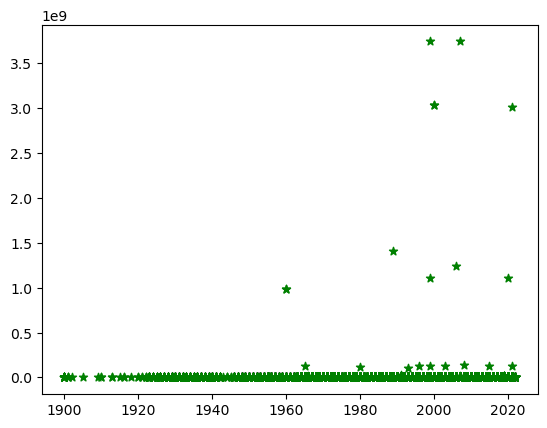

In [41]:
plt.scatter(x='year', y='price', data=vehicles_raw, color='green', marker='*')

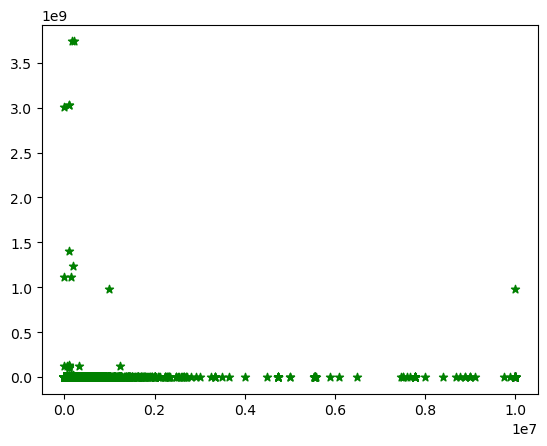

In [42]:
plt.scatter(x='odometer', y='price', data=vehicles_raw, color='green', marker='*')

### Removing outliers for price and odometer.

In [44]:
price_low = vehicles_raw["price"].quantile(0.20)
price_hi  = vehicles_raw["price"].quantile(0.80)

odometer_low = vehicles_raw["odometer"].quantile(0.20)
odometer_hi  = vehicles_raw["odometer"].quantile(0.80)

price_low, price_hi, odometer_low, odometer_hi

(5999.0, 30000.0, 30061, 147446)

In [45]:
df_filtered = vehicles_raw[(vehicles_raw["price"] < price_hi) & (vehicles_raw["price"] > price_low)]
df_filtered

,price,year,manufacturer,fuel,odometer,title_status,transmission,state
0,6000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,az
1,11900,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ar
2,21000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,fl
7,15995,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ny
15,13995,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,wa
...,...,...,...,...,...,...,...,...
426869,13990,2016,<NA>,other,75626,clean,other,wy
426870,22990,2020,hyundai,gas,3066,clean,other,wy
426871,17990,2018,kia,gas,34239,clean,other,wy
426875,23590,2019,nissan,gas,32226,clean,other,wy


In [46]:
df_filtered = df_filtered[(df_filtered["odometer"] < odometer_hi) & (df_filtered["odometer"] > odometer_low)]
vehicles_clean = df_filtered
vehicles_clean

,price,year,manufacturer,fuel,odometer,title_status,transmission,state
28,22590,2010,chevrolet,gas,71229,clean,other,al
31,15000,2013,ford,gas,128000,clean,automatic,al
32,27990,2012,gmc,gas,68696,clean,other,al
39,24590,2017,chevrolet,gas,40784,clean,other,al
45,27990,2018,nissan,gas,37332,clean,other,al
...,...,...,...,...,...,...,...,...
426864,29590,2016,toyota,gas,53475,clean,automatic,wy
426869,13990,2016,<NA>,other,75626,clean,other,wy
426871,17990,2018,kia,gas,34239,clean,other,wy
426875,23590,2019,nissan,gas,32226,clean,other,wy


In [47]:
(vehicles_clean.isnull().sum().sum()/vehicles_clean.shape[0])*100

6.381369747534542

### Removing 6% of NULL data.

In [51]:
vehicles_clean = vehicles_clean.dropna()
vehicles_clean.isnull().sum()

price           0
year            0
manufacturer    0
fuel            0
odometer        0
title_status    0
transmission    0
state           0
dtype: int64

In [52]:
vehicles_clean

,price,year,manufacturer,fuel,odometer,title_status,transmission,state
28,22590,2010,chevrolet,gas,71229,clean,other,al
31,15000,2013,ford,gas,128000,clean,automatic,al
32,27990,2012,gmc,gas,68696,clean,other,al
39,24590,2017,chevrolet,gas,40784,clean,other,al
45,27990,2018,nissan,gas,37332,clean,other,al
...,...,...,...,...,...,...,...,...
426855,7477,2012,fiat,gas,64267,clean,manual,wy
426864,29590,2016,toyota,gas,53475,clean,automatic,wy
426871,17990,2018,kia,gas,34239,clean,other,wy
426875,23590,2019,nissan,gas,32226,clean,other,wy


### Correlation map of price and other features

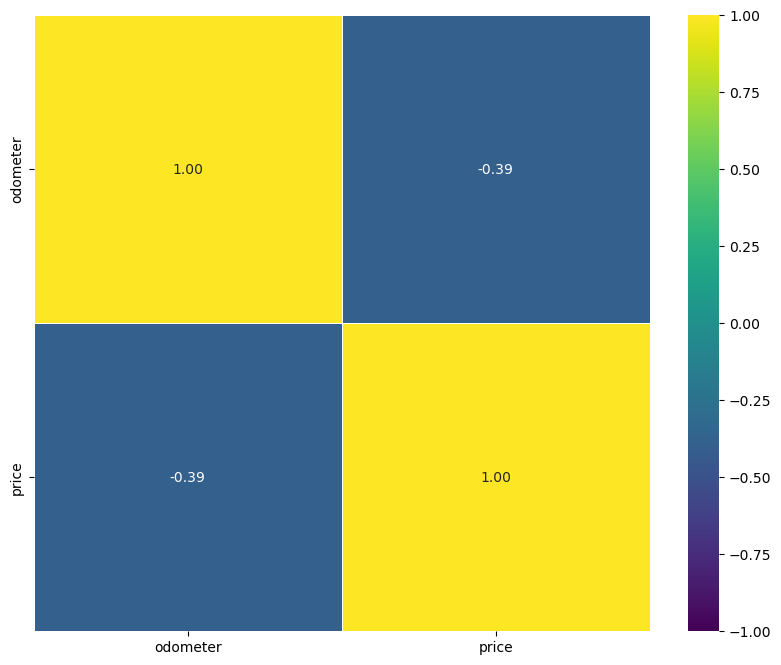

In [54]:
odometer = vehicles_clean[['odometer','price']]
plt.figure(figsize = (10,8))
sns.heatmap(odometer.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

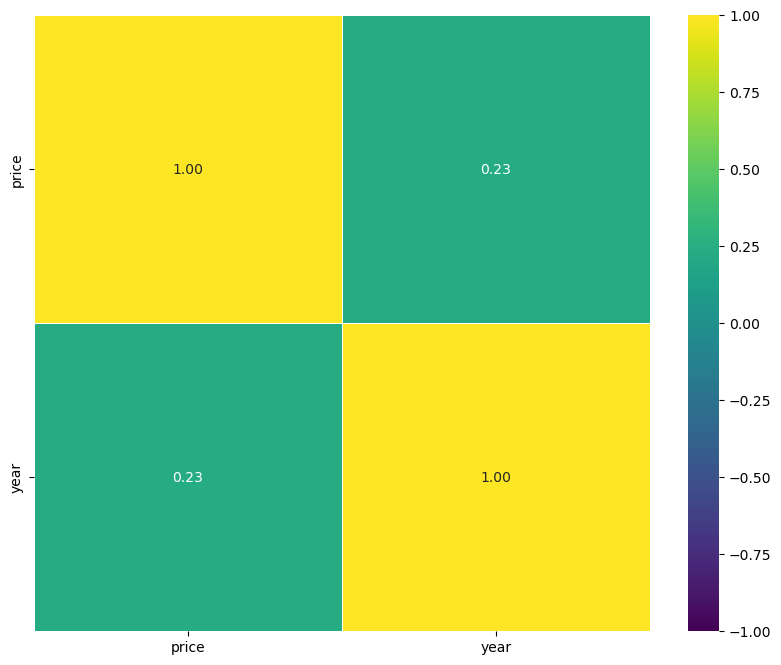

In [55]:
year = vehicles_clean[['price','year']]
plt.figure(figsize = (10,8))
sns.heatmap(year.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

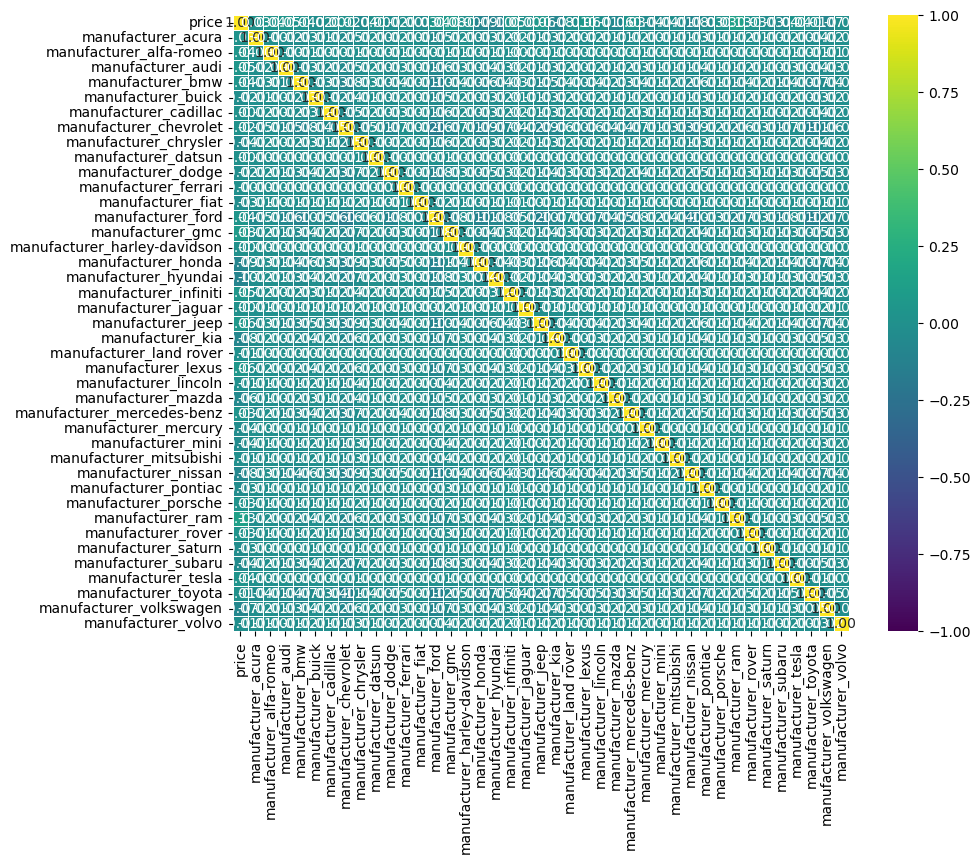

In [56]:
manufacturer = vehicles_clean[['manufacturer','price']]
manufacturer = pd.get_dummies(manufacturer, columns=['manufacturer'])
plt.figure(figsize = (10,8))
sns.heatmap(manufacturer.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

In [57]:
manufacturer.corr(numeric_only=True)[['price']].nlargest(columns = 'price', n = 10)

,price
price,1.000000
manufacturer_ram,0.131584
manufacturer_gmc,0.083016
manufacturer_jeep,0.064648
manufacturer_lexus,0.058567
manufacturer_infiniti,0.051046
manufacturer_audi,0.047023
manufacturer_ford,0.044951
manufacturer_alfa-romeo,0.044467
manufacturer_bmw,0.038304


### Manufacturer does not make signficante influence - Hence will be dropped for further analysis

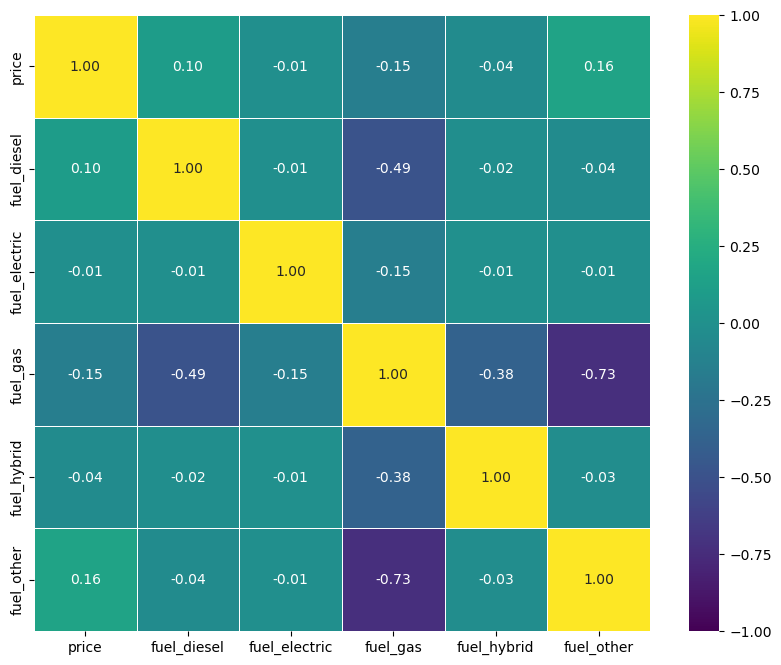

In [59]:
fuel = vehicles_clean[['fuel','price']]
fuel = pd.get_dummies(fuel, columns=['fuel'])
plt.figure(figsize = (10,8))
sns.heatmap(fuel.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

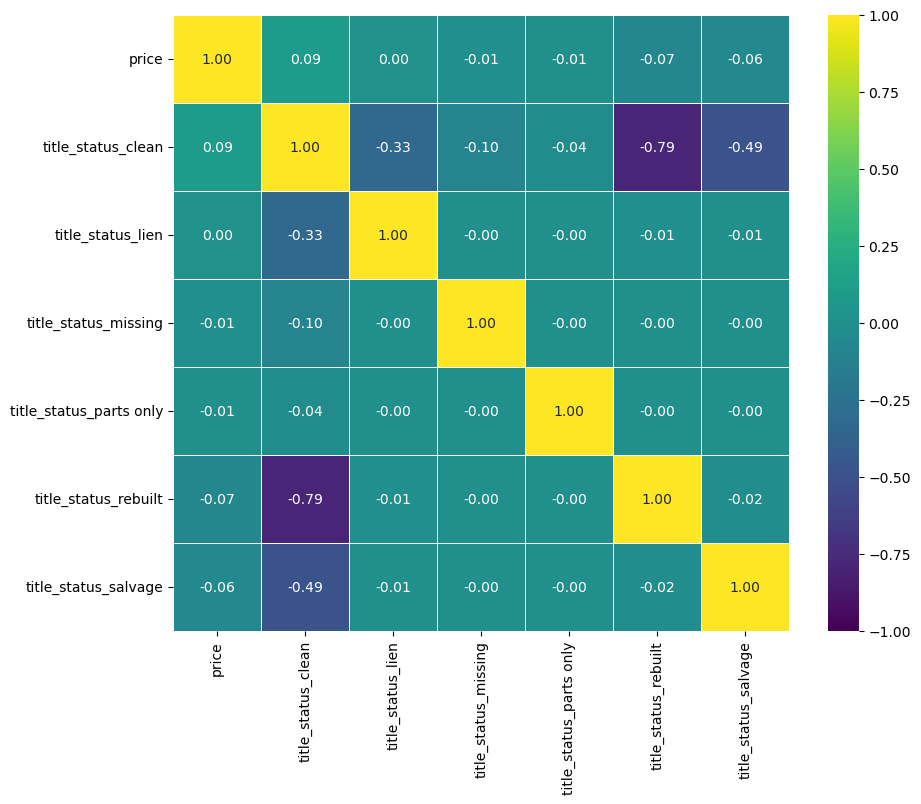

In [60]:
title_status = vehicles_clean[['title_status','price']]
title_status = pd.get_dummies(title_status, columns=['title_status'])
plt.figure(figsize = (10,8))
sns.heatmap(title_status.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

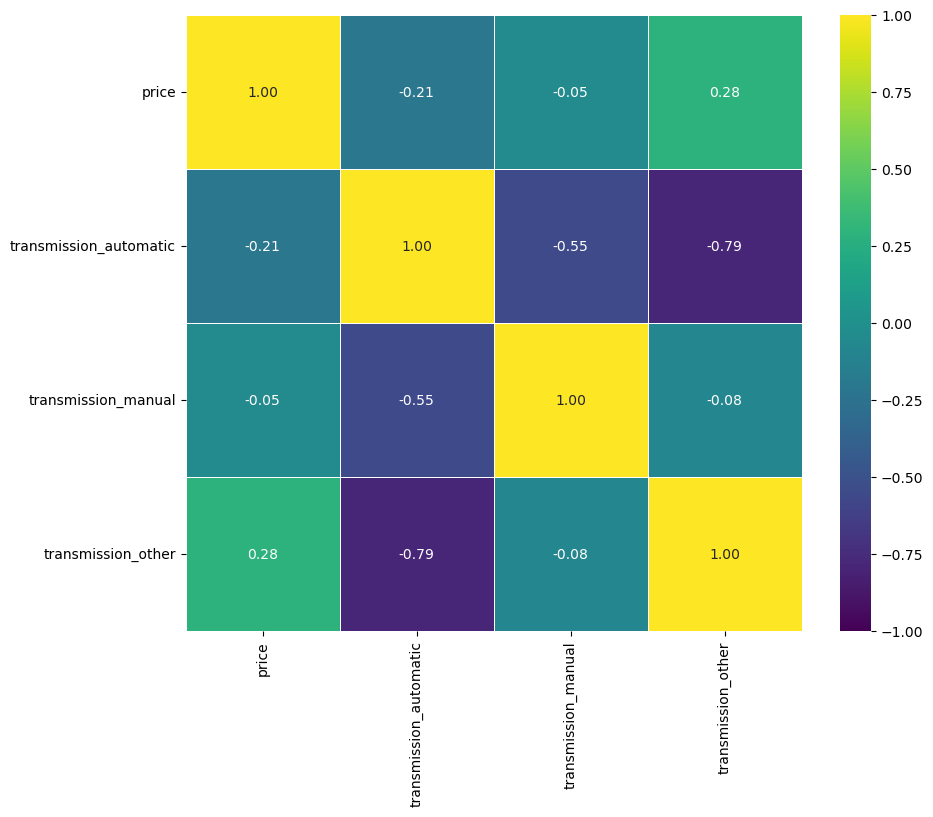

In [61]:
transmission = vehicles_clean[['transmission','price']]
transmission = pd.get_dummies(transmission, columns=['transmission'])
plt.figure(figsize = (10,8))
sns.heatmap(transmission.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

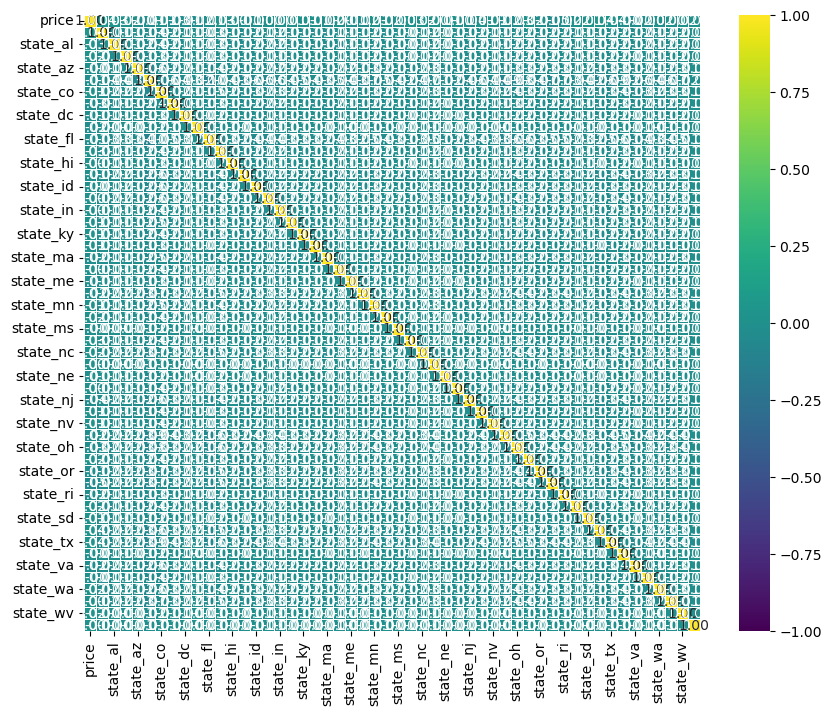

In [62]:
state = vehicles_clean[['state','price']]
state = pd.get_dummies(state, columns=['state'])
plt.figure(figsize = (10,8))
sns.heatmap(state.corr(),cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

In [63]:
state.corr(numeric_only=True)[['price']].nlargest(columns = 'price', n = 10)

,price
price,1.000000
state_tn,0.041627
state_ak,0.040615
state_tx,0.036873
state_al,0.033289
state_mt,0.032720
state_ga,0.026005
state_wv,0.021734
state_nc,0.021732
state_mo,0.020809


### State does not make significante influence to the price - Hence will be remove for further analysis

In [65]:
vehicles_clean = vehicles_clean.drop('state',axis=1)
vehicles_clean = vehicles_clean.drop('manufacturer',axis=1)
vehicles_clean

,price,year,fuel,odometer,title_status,transmission
28,22590,2010,gas,71229,clean,other
31,15000,2013,gas,128000,clean,automatic
32,27990,2012,gas,68696,clean,other
39,24590,2017,gas,40784,clean,other
45,27990,2018,gas,37332,clean,other
...,...,...,...,...,...,...
426855,7477,2012,gas,64267,clean,manual
426864,29590,2016,gas,53475,clean,automatic
426871,17990,2018,gas,34239,clean,other
426875,23590,2019,gas,32226,clean,other


In [66]:
vehicles_clean.describe()

,price,year,odometer
count,151649.0,151649.0,151649.0
mean,15993.728768,2011.707133,87473.62433
std,6748.47226,7.706606,32322.271365
min,6000.0,1918.0,30063.0
25%,9995.0,2011.0,61000.0
50%,14995.0,2013.0,88410.0
75%,20995.0,2016.0,113824.0
max,29999.0,2021.0,147445.0


In [67]:
vehicles = pd.get_dummies(vehicles_clean, columns = ['fuel','title_status','transmission'])

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Split the data (70/30) - Creating two sets of same dataset. One with year and odometer (no categorical feature) and another with all features that are in now.

In [70]:
vehicles

,price,year,odometer,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,title_status_clean,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,transmission_automatic,transmission_manual,transmission_other
28,22590,2010,71229,False,False,True,False,False,True,False,False,False,False,False,False,False,True
31,15000,2013,128000,False,False,True,False,False,True,False,False,False,False,False,True,False,False
32,27990,2012,68696,False,False,True,False,False,True,False,False,False,False,False,False,False,True
39,24590,2017,40784,False,False,True,False,False,True,False,False,False,False,False,False,False,True
45,27990,2018,37332,False,False,True,False,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426855,7477,2012,64267,False,False,True,False,False,True,False,False,False,False,False,False,True,False
426864,29590,2016,53475,False,False,True,False,False,True,False,False,False,False,False,True,False,False
426871,17990,2018,34239,False,False,True,False,False,True,False,False,False,False,False,False,False,True
426875,23590,2019,32226,False,False,True,False,False,True,False,False,False,False,False,False,False,True


In [71]:
vehicles.columns

Index(['price', 'year', 'odometer', 'fuel_diesel', 'fuel_electric', 'fuel_gas',
       'fuel_hybrid', 'fuel_other', 'title_status_clean', 'title_status_lien',
       'title_status_missing', 'title_status_parts only',
       'title_status_rebuilt', 'title_status_salvage',
       'transmission_automatic', 'transmission_manual', 'transmission_other'],
      dtype='object')

In [72]:
X = vehicles.drop('price',axis=1)
y = vehicles['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=22)

In [73]:
XS_train = X_train[['year','odometer']]
XS_test = X_test[['year','odometer']]

In [74]:
params_dict = {'ridge__alpha': 10**np.linspace(-5,4,10)}
column_names = ['mName', 'train_mse', 'test_mse', 'type', 'hp']
df_model = pd.DataFrame(columns=column_names)
grid_ridge_intfeature_train = []
grid_ridge_intfeature_test = []
grid_ridge_feature_train = []
grid_ridge_feature_test = []
grid_lasso_feature_train = []
grid_lasso_feature_test = []


###  Creating two Functions for Ridge Grid analysis

In [76]:
def Grid_Ridge_IntFeature(i):
    ridge_pipe_xs = Pipeline([('polynomial', PolynomialFeatures(degree=i, include_bias=False)), ('scaler', StandardScaler()), ('ridge', Ridge())])
    grid_ridge_xs = GridSearchCV(estimator=ridge_pipe_xs,param_grid=params_dict, cv=5)
    grid_ridge_xs.fit(XS_train, y_train)
    train_preds_s = grid_ridge_xs.predict(XS_train)
    test_preds_s = grid_ridge_xs.predict(XS_test)
    train_mse = mean_squared_error(y_train, train_preds_s)
    test_mse = mean_squared_error(y_test, test_preds_s)
    df = pd.DataFrame({'feature': grid_ridge_xs.best_estimator_.named_steps.polynomial.get_feature_names_out(),
                       'coef': grid_ridge_xs.best_estimator_.named_steps.ridge.coef_})
    return [train_mse, test_mse, train_preds_s, test_preds_s, grid_ridge_xs.best_score_, grid_ridge_xs.best_params_, df]

def Grid_Ridge_Feature(i):
    ridge_pipe = Pipeline([('polynomial', PolynomialFeatures(degree=i, include_bias=False)), ('scaler', StandardScaler()), ('ridge', Ridge())])
    grid_ridge = GridSearchCV(estimator=ridge_pipe,param_grid=params_dict, cv=5)
    grid_ridge.fit(X_train, y_train)
    train_preds = grid_ridge.predict(X_train)
    test_preds = grid_ridge.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    df = pd.DataFrame({'feature': grid_ridge.best_estimator_.named_steps.polynomial.get_feature_names_out(),
                       'coef': grid_ridge.best_estimator_.named_steps.ridge.coef_})
    return [train_mse,test_mse, train_preds, test_preds, grid_ridge.best_score_, grid_ridge.best_params_, pd]

### Calling the method for several Polynomial Features, Storing the mse of both training data and test data. Uses only year and odometer.

In [78]:
for degree in [1,2,3,4,5]:
    a1, a2, a3, a4, a5, a6, a7 = Grid_Ridge_IntFeature(degree)
    grid_ridge_intfeature_train.append(a3)
    grid_ridge_intfeature_test.append(a4)
    df_model.loc[len(df_model)] = ["Grid_Ridge_IntFeature_" + str(degree), a1, a2,'ridgeS',a6]
    print(a1,a2,a5,a6, a7)

37283458.06050675 37083119.404704936 0.18060589488121423 {'ridge__alpha': 10.0}     feature         coef
0      year  1126.770358
1  odometer -2452.376839
35602832.27900505 35453900.70865593 0.2173857758998599 {'ridge__alpha': 0.01}          feature           coef
0           year -208957.811586
1       odometer   16436.704797
2         year^2  210334.081451
3  year odometer  -20918.471626
4     odometer^2    2524.397626
35023288.84501066 34865344.66661542 0.22998848089767332 {'ridge__alpha': 1e-05}            feature          coef
0             year  1.170120e+07
1         odometer  3.383594e+06
2           year^2 -2.364473e+07
3    year odometer -6.795259e+06
4       odometer^2 -7.702960e+03
5           year^3  1.194534e+07
6  year^2 odometer  3.409215e+06
7  year odometer^2  6.597215e+03
8       odometer^3  2.051455e+03
35001119.17472748 34829321.649041384 0.2305945327461937 {'ridge__alpha': 1e-05}               feature          coef
0                year  6.781276e+06
1            

### Calling the method for several Polynomial Features, Storing the mse of both training data and test data

In [80]:
for degree in [1,2,3]:
    a1, a2, a3, a4, a5,  a6, a7 = Grid_Ridge_Feature(degree)
    grid_ridge_feature_train.append(a3)
    grid_ridge_feature_test.append(a4)
    df_model.loc[len(df_model)] = ["Grid_Ridge_Feature_" + str(degree), a1, a2,'ridge',a6]
    print(a1,a2,a5,a6,a7)

34566104.44764907 34290339.079408154 0.24008333380878666 {'ridge__alpha': 100.0} <module 'pandas' from 'C:\\Users\\Ansuman\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>
32409888.49622431 32413005.19103069 0.28566934536841104 {'ridge__alpha': 0.1} <module 'pandas' from 'C:\\Users\\Ansuman\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>
32307118.068896394 32359715.271798607 0.27633228852626646 {'ridge__alpha': 1.0} <module 'pandas' from 'C:\\Users\\Ansuman\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>


In [81]:
df_model

,mName,train_mse,test_mse,type,hp
0,Grid_Ridge_IntFeature_1,3.728346e+07,3.708312e+07,ridgeS,{'ridge__alpha': 10.0}
1,Grid_Ridge_IntFeature_2,3.560283e+07,3.545390e+07,ridgeS,{'ridge__alpha': 0.01}
2,Grid_Ridge_IntFeature_3,3.502329e+07,3.486534e+07,ridgeS,{'ridge__alpha': 1e-05}
3,Grid_Ridge_IntFeature_4,3.500112e+07,3.482932e+07,ridgeS,{'ridge__alpha': 1e-05}
4,Grid_Ridge_IntFeature_5,3.499658e+07,3.482186e+07,ridgeS,{'ridge__alpha': 1e-05}
5,Grid_Ridge_Feature_1,3.456610e+07,3.429034e+07,ridge,{'ridge__alpha': 100.0}
6,Grid_Ridge_Feature_2,3.240989e+07,3.241301e+07,ridge,{'ridge__alpha': 0.1}
7,Grid_Ridge_Feature_3,3.230712e+07,3.235972e+07,ridge,{'ridge__alpha': 1.0}


###  Creating a function for Lasso Grid analysis

In [83]:
def Grid_Lasso_Feature(i):
    ridge_pipe = Pipeline([('polynomial', PolynomialFeatures(degree=i, include_bias=False)), ('scaler', StandardScaler()), ('ridge', Lasso())])
    grid_ridge = GridSearchCV(estimator=ridge_pipe,param_grid=params_dict, cv=5)
    grid_ridge.fit(X_train, y_train)
    train_preds = grid_ridge.predict(X_train)
    test_preds = grid_ridge.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    df = pd.DataFrame({'feature': grid_ridge.best_estimator_.named_steps.polynomial.get_feature_names_out(),
                       'coef': grid_ridge.best_estimator_.named_steps.ridge.coef_})
    return [train_mse,test_mse, train_preds, test_preds, grid_ridge.best_score_, grid_ridge.best_params_,pd]

### Calling the method for several Polynomial Features, Storing the mse of both training data and test data

In [85]:
degrees = [1,2]
for degree in degrees:
    a1, a2, a3, a4, a5, a6, a7 = Grid_Lasso_Feature(degree)
    grid_lasso_feature_train.append(a3)
    grid_lasso_feature_test.append(a4)
    df_model.loc[len(df_model)] = ["Grid_Lasso_Feature_" + str(degree), a1, a2,'lasso',a6]
    print(a1,a2,a5,a6, a7)

C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.282e+10, tolerance: 3.863e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.318e+10, tolerance: 3.871e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.411e+10, to

34566098.04272088 34289972.35737281 0.2400831278455407 {'ridge__alpha': 1e-05} <module 'pandas' from 'C:\\Users\\Ansuman\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>


C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.440e+12, tolerance: 3.863e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.446e+12, tolerance: 3.871e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\Ansuman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.443e+12, to

33939507.18961491 33767669.499145426 0.2531203923135436 {'ridge__alpha': 0.1} <module 'pandas' from 'C:\\Users\\Ansuman\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>


###  Creating a function for SFS Pipeline without PolynomialFeature

In [87]:
grid_sfs_feature_train = []
grid_sfs_feature_test = []
grid_sfs_polyfeature_train = []
grid_sfs_polyfeature_test = []

In [88]:
def Get_SFS(i):
    selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=i)
    pipe = Pipeline([('sfs', selector), ('scaler', StandardScaler()), ('linreg', LinearRegression())])
    pipe.fit(X_train, y_train)
    train_preds = pipe.predict(X_train)
    test_preds = pipe.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    df = pd.DataFrame({'feature': pipe.named_steps.sfs.get_feature_names_out(),
                       'coef': pipe.named_steps.linreg.coef_})
    return [train_mse, test_mse, train_preds, test_preds, df]

In [89]:
degrees = [1,2,3,4,5,6,7,8,9,10]
for degree in degrees:
    a1, a2, a3, a4, a5 = Get_SFS(degree)
    grid_sfs_feature_train.append(a3)
    grid_sfs_feature_test.append(a4)
    df_model.loc[len(df_model)] = ["SFS" + str(degree), a1, a2,'sfsS',""]
    print(a1,a2,a5)

38516509.80509735 38340020.14942244     feature         coef
0  odometer -2644.207224
37283458.00253263 37083094.137150876     feature         coef
0      year  1126.839210
1  odometer -2452.596151
36265157.904569946 36033268.88706858               feature         coef
0                year  1037.798019
1            odometer -2114.314377
2  transmission_other  1072.803208
35502064.217568286 35214517.37640614               feature         coef
0                year  1101.759170
1            odometer -2157.425988
2         fuel_diesel   877.320587
3  transmission_other  1065.243889
35024031.81913361 34782264.73000345               feature         coef
0                year  1121.314237
1            odometer -2213.497001
2         fuel_diesel   880.110153
3  title_status_clean   695.207841
4  transmission_other  1001.177317
34825975.73281033 34608400.33835191               feature         coef
0                year  1105.398681
1            odometer -2212.948982
2         fuel_diesel   89

###  Creating a function for SFS Pipeline with PolynomialFeature

In [91]:
def Get_PolySFS(i):
    pipe = Pipeline([('polynomial', PolynomialFeatures(degree = i, include_bias = False)),
                     ('sfs', SequentialFeatureSelector(LinearRegression(), n_features_to_select=i)),
                     ('scaler', StandardScaler()),
                     ('linreg', LinearRegression())])
    #grid = GridSearchCV(estimator=pipe, param_grid = parameters , cv=5)
    pipe.fit(X_train, y_train)
    train_preds = pipe.predict(X_train)
    test_preds = pipe.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    df = pd.DataFrame({'feature': pipe.named_steps.sfs.get_feature_names_out(),
                   'coef': pipe.named_steps.linreg.coef_})
    return [train_mse, test_mse, train_preds, test_mse, df]

In [92]:
degrees = [1,2,3]
for degree in degrees:
    a1, a2, a3, a4, a5 = Get_PolySFS(degree)
    grid_sfs_polyfeature_train.append(a3)
    grid_sfs_polyfeature_test.append(a4)
    df_model.loc[len(df_model)] = ["SFS" + str(degree), a1, a2,'sfs',""]
    print(a1,a2,a5)

38516509.80509735 38340020.14942244   feature         coef
0      x1 -2644.207224
37268008.401281215 37067735.85828554   feature         coef
0      x1 -2449.095779
1     x16  1134.270638
35798112.55647422 35588725.50681398   feature           coef
0      x1   -2010.442823
1     x16 -214944.348669
2    x152  216157.906148


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Sort the model data based on mse on test data set

In [95]:
df_model = df_model.sort_values(by='test_mse')
df_model

,mName,train_mse,test_mse,type,hp
7,Grid_Ridge_Feature_3,3.230712e+07,3.235972e+07,ridge,{'ridge__alpha': 1.0}
6,Grid_Ridge_Feature_2,3.240989e+07,3.241301e+07,ridge,{'ridge__alpha': 0.1}
9,Grid_Lasso_Feature_2,3.393951e+07,3.376767e+07,lasso,{'ridge__alpha': 0.1}
8,Grid_Lasso_Feature_1,3.456610e+07,3.428997e+07,lasso,{'ridge__alpha': 1e-05}
5,Grid_Ridge_Feature_1,3.456610e+07,3.429034e+07,ridge,{'ridge__alpha': 100.0}
19,SFS10,3.456917e+07,3.429969e+07,sfsS,
18,SFS9,3.457435e+07,3.430411e+07,sfsS,
17,SFS8,3.458902e+07,3.430812e+07,sfsS,
16,SFS7,3.466033e+07,3.441164e+07,sfsS,
15,SFS6,3.482598e+07,3.460840e+07,sfsS,


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Best model for the price estimation
Grid_Ridge_Feature(3)

